In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

from sklearn.decomposition import PCA


## Carregamento dos Dados

In [9]:
df = pd.read_csv("fraude.csv")
df.head()


,Valor,Periodo,Classe
0,2500,Diurno,Normal
1,1500,Diurno,Normal
2,700,Diurno,Normal
3,3700,Diurno,Normal
4,5600,Diurno,Normal


## Pré-processamento

In [10]:
data = df.copy()

data = data.dropna(subset=["Classe"])

data["Valor"] = data["Valor"].fillna(data["Valor"].median())
data["Periodo"] = data["Periodo"].fillna("Desconhecido")

X = data[["Valor", "Periodo"]]
y = data["Classe"].astype(str)


numeric_features = ["Valor"]
categorical_features = ["Periodo"]

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X_transformed = preprocessor.fit_transform(X)
X_transformed.shape


(38, 3)

## Divisão do Dataset para Treino e Treino KNN

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_transformed, y, test_size=0.25, random_state=42, stratify=y
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn, rec_knn, f1_knn, _ = precision_recall_fscore_support(
    y_test, y_pred_knn, average="macro"
)
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("KNN - Desempenho (teste)")
print("Accuracy:", acc_knn)
print("Precision:", prec_knn)
print("Recall:", rec_knn)
print("F1:", f1_knn)
print("\nMatriz de Confusão:\n", cm_knn)
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))


KNN - Desempenho (teste)
Accuracy: 0.8
Precision: 0.4
Recall: 0.5
F1: 0.4444444444444444

Matriz de Confusão:
 [[0 2]
 [0 8]]

Classification Report:
               precision    recall  f1-score   support

      Fraude       0.00      0.00      0.00         2
      Normal       0.80      1.00      0.89         8

    accuracy                           0.80        10
   macro avg       0.40      0.50      0.44        10
weighted avg       0.64      0.80      0.71        10



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

## Treinamento Kmeans

In [12]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_transformed)

ari = adjusted_rand_score(y, clusters)
nmi = normalized_mutual_info_score(y, clusters)

print("K-Means - Métricas não supervisionadas")
print("ARI:", ari)
print("NMI:", nmi)


K-Means - Métricas não supervisionadas
ARI: 0.10145005607275256
NMI: 0.026805912334793566


## Mapeamento dos Clusters

In [13]:
mapping = {}
for cluster_id in np.unique(clusters):
    mask = clusters == cluster_id
    mapping[cluster_id] = pd.Series(y[mask]).mode()[0]

mapping


{np.int32(0): 'Normal', np.int32(1): 'Normal'}

## Avaliação do Mapeamento

In [14]:
y_pred_kmeans = np.array([mapping[c] for c in clusters])

mapped_acc = accuracy_score(y, y_pred_kmeans)
cm_kmeans = confusion_matrix(y, y_pred_kmeans)

print("Acurácia do K-Means após mapeamento:", mapped_acc)
print("\nMatriz de Confusão:\n", cm_kmeans)


Acurácia do K-Means após mapeamento: 0.8421052631578947

Matriz de Confusão:
 [[ 0  6]
 [ 0 32]]


## Visualizações

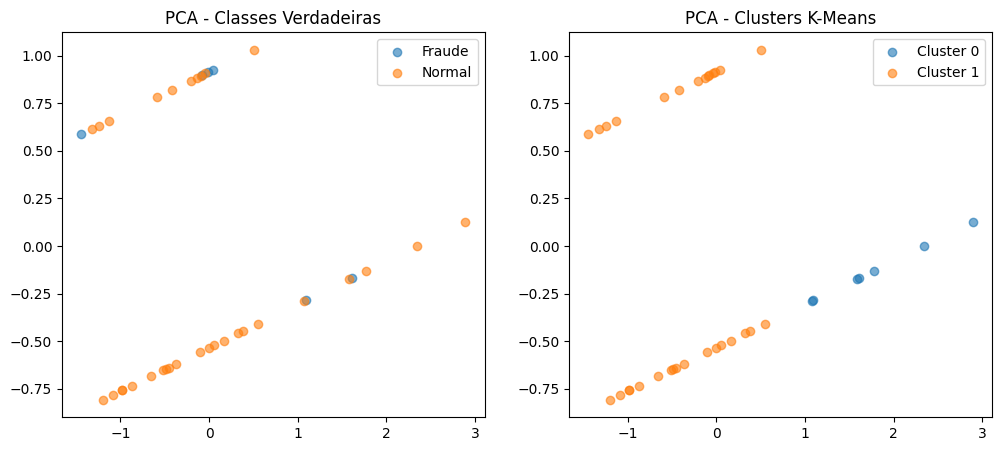

In [15]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_transformed)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
for c in np.unique(y):
    mask = (y == c)
    plt.scatter(pca_data[mask, 0], pca_data[mask, 1], label=c, alpha=0.6)
plt.title("PCA - Classes Verdadeiras")
plt.legend()

plt.subplot(1,2,2)
for cl in np.unique(clusters):
    mask = (clusters == cl)
    plt.scatter(pca_data[mask, 0], pca_data[mask, 1], label=f"Cluster {cl}", alpha=0.6)
plt.title("PCA - Clusters K-Means")
plt.legend()

plt.show()
